#  Smart Portfolio Optimizer

## Modern Portfolio Theory (MPT) - Learning Notebook

This notebook walks you through building a portfolio optimizer step-by-step, explaining each concept along the way.

### What You'll Learn:
1. **Data Fetching** - Getting real stock prices with yfinance
2. **Returns Calculation** - Simple vs Log returns, annualization
3. **Portfolio Statistics** - Covariance matrix, correlation, portfolio math
4. **Monte Carlo Simulation** - Generating thousands of random portfolios
5. **Optimization** - Finding Max Sharpe and Min Volatility portfolios
6. **Visualization** - The famous Efficient Frontier chart

---

# 1. Setting Up the Environment

### Required Libraries:
- **yfinance**: Free API to fetch stock data from Yahoo Finance
- **pandas**: Data manipulation (think Excel in Python)
- **numpy**: Mathematical operations, matrix calculations
- **matplotlib**: Creating charts and visualizations

In [1]:
# Import all required libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# 2. Configuration Variables

Customize your analysis by modifying these variables:

In [ ]:
# Stocks to analyze
TICKERS = ['AAPL', 'GOOGL', 'MSFT', 'AMZN', 'BND', 'XOM', 'AGG', 'JNJ', 'V', 'PG']  # Tech + Bonds + Diversification

# Date range for historical data
START_DATE = '2024-01-01'
END_DATE = '2026-01-01'

# Simulation parameters
N_PORTFOLIOS = 10000  # More = smoother frontier but slower
TRADING_DAYS = 252     # Trading days per year

# Risk-free rate: using ~5% US Treasury rate as of 2024.
# This changes over time! Check current rates at:
# https://www.treasury.gov/resource-center/data-chart-center/interest-rates/
# In a production system you'd fetch this dynamically.
RISK_FREE_RATE = 0.05

print(f"📊 Configuration:")
print(f"   Tickers: {TICKERS}")
print(f"   Period: {START_DATE} to {END_DATE}")
print(f"   Portfolios to simulate: {N_PORTFOLIOS:,}")
print(f"   Risk-free rate: {RISK_FREE_RATE:.0%} (check if still current!)")

---

# 3. Data Fetching

### Concept: Getting Historical Stock Prices

Before we can optimize a portfolio, we need **historical price data**.

**Key Terms:**
- **Ticker**: Stock symbol (e.g., 'AAPL' = Apple)
- **Close Price**: The final trading price each day (adjusted for dividends/splits)
- **DataFrame**: A 2D table - rows are dates, columns are stocks

In [3]:
def fetch_stock_data(tickers, start_date, end_date):
    """Download adjusted close prices and return a clean DataFrame."""
    data = yf.download(
        tickers,
        start=start_date,
        end=end_date,
        auto_adjust=True,
        progress=False
    )

    # yfinance returns MultiIndex columns for multiple tickers.
    if isinstance(data.columns, pd.MultiIndex):
        prices = data['Close'].copy()
    else:
        # Single ticker path: convert Close to a one-column DataFrame.
        ticker_name = tickers if isinstance(tickers, str) else tickers[0]
        prices = data[['Close']].rename(columns={'Close': ticker_name})

    prices = prices.dropna(how='all').ffill().dropna()
    return prices

In [4]:
# Fetch the stock data
prices = fetch_stock_data(TICKERS, START_DATE, END_DATE)

# Get actual column order (yfinance sorts alphabetically)
actual_tickers = list(prices.columns)

print(f"✅ Loaded {len(prices)} trading days of data")
print(f"📋 Columns: {actual_tickers}")
print(f"\n First 5 days:")
prices.head()

✅ Loaded 502 trading days of data
📋 Columns: ['AAPL', 'AGG', 'AMZN', 'BND', 'GOOGL', 'JNJ', 'MSFT', 'PG', 'V', 'XOM']

 First 5 days:


Ticker,AAPL,AGG,AMZN,BND,GOOGL,JNJ,MSFT,PG,V,XOM
Date,,,,,,,,,,
2024-01-02,183.731308,90.957588,149.929993,67.510513,137.037384,149.659760,364.589417,140.394638,254.569504,94.847115
2024-01-03,182.355606,91.003632,148.470001,67.565819,137.781235,150.595306,364.324036,139.545120,253.694305,95.643990
2024-01-04,180.039642,90.635307,144.570007,67.261650,135.271988,150.277222,361.709076,140.309677,255.297180,94.810059
2024-01-05,179.317139,90.423523,145.240005,67.058853,134.617401,150.745010,361.522308,139.148712,255.375916,95.097313
2024-01-08,183.652130,90.764229,149.100006,67.353813,137.701889,151.119232,368.344757,140.347412,258.178589,93.512817


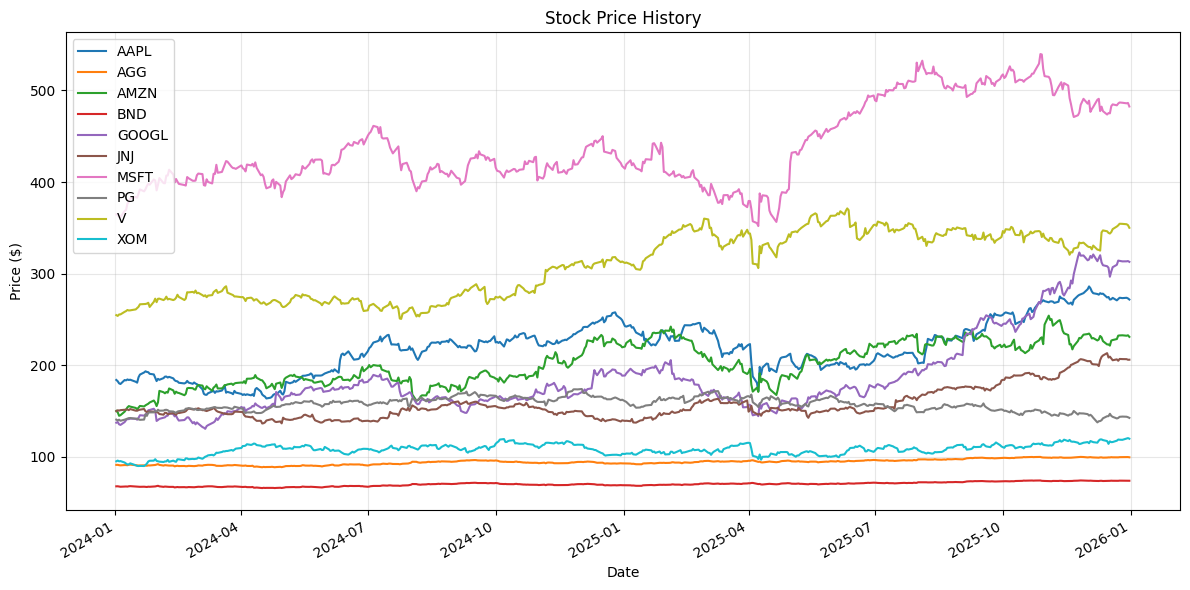

In [5]:
# Quick visualization of price history
prices.plot(figsize=(12, 6), title='Stock Price History')
plt.ylabel('Price ($)')
plt.xlabel('Date')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

# 4. Calculating Returns

### Why Returns Instead of Prices?

- A $10 stock going to $11 is the same 10% gain as $100 → $110
- Returns are **comparable** across different price levels
- We can calculate statistics (mean, std) on returns

### Two Types of Returns:

| Type | Formula | Use Case |
|------|---------|----------|
| **Simple** | $(P_t - P_{t-1}) / P_{t-1}$ | Intuitive ("stock up 5%") |
| **Log** | $\ln(P_t / P_{t-1})$ | Can be summed across time, better for stats (closer to a normal distribution) |

For small daily moves, they're nearly identical!

### Important Note: Log vs Simple Returns in Portfolio Math

Strictly speaking, **Markowitz portfolio theory assumes simple (arithmetic) returns**, because:
$$R_p = \sum w_i \times R_i \quad \text{(only true for simple returns)}$$

Log returns do NOT sum across assets this way. We use log returns here because they're better for statistical estimation (covariance, mean). For **daily** data the numerical difference is tiny (< 0.01%), so this is a standard practical shortcut. Just be aware that for longer time horizons or very volatile assets, you'd want to use simple returns for the portfolio math.

In [6]:
def calculate_log_returns(prices):
    """
    Calculate logarithmic returns: r_t = ln(P_t / P_{t-1})
    
    Why log returns?
    - Can be summed across time periods
    - Symmetric: -5% and +5% are truly opposite
    - Better for statistical analysis
    """
    log_returns = np.log(prices).diff().dropna()
    return log_returns


def annualize_returns(daily_returns, trading_days=252):
    """
    Convert daily returns to annualized expected returns.
    Formula: μ_annual = mean(daily) × 252
    """
    return daily_returns.mean() * trading_days


def annualize_volatility(daily_returns, trading_days=252):
    """
    Convert daily volatility to annualized.
    Formula: σ_annual = std(daily) × √252
    
    Why √252? Variance adds, so std = √(var × days) = std × √days
    """
    return daily_returns.std() * np.sqrt(trading_days)

In [7]:
# Calculate daily log returns
daily_returns = calculate_log_returns(prices)

print("📊 Daily Log Returns (first 5 days):")
daily_returns.head()

📊 Daily Log Returns (first 5 days):


Ticker,AAPL,AGG,AMZN,BND,GOOGL,JNJ,MSFT,PG,V,XOM
Date,,,,,,,,,,
2024-01-03,-0.007516,0.000506,-0.009786,0.000819,0.005413,0.006232,-0.000728,-0.006069,-0.003444,0.008367
2024-01-04,-0.012782,-0.004056,-0.026619,-0.004512,-0.018380,-0.002114,-0.007203,0.005464,0.006298,-0.008757
2024-01-05,-0.004021,-0.002339,0.004624,-0.003020,-0.004851,0.003108,-0.000516,-0.008309,0.000308,0.003025
2024-01-08,0.023887,0.003761,0.026230,0.004389,0.022654,0.002479,0.018696,0.008578,0.010915,-0.016802
2024-01-09,-0.002266,-0.000203,0.015110,-0.000137,0.015083,0.000619,0.002932,0.004094,0.003004,-0.012464


### Sharpe Ratio

The **Sharpe Ratio** measures return per unit of risk taken.

It is defined as:

$$
\text{Sharpe Ratio} = \frac{R_p - R_f}{\sigma_p}
$$

- $R_p$: portfolio return
- $R_f$: risk-free rate
- $\sigma_p$: portfolio volatility (standard deviation of returns)

Interpretation:
- Higher Sharpe means better risk-adjusted performance.
- Sharpe > 1 is often considered good.
- Sharpe < 1 suggests limited return relative to risk.

In [8]:
# Annualize the metrics
annual_returns = annualize_returns(daily_returns)
annual_volatility = annualize_volatility(daily_returns)

# Calculate Sharpe ratios for individual stocks
sharpe_ratios = (annual_returns - RISK_FREE_RATE) / annual_volatility

print("📈 INDIVIDUAL STOCK METRICS")
print("=" * 50)
print(f"{'Ticker':<8} {'Return':>12} {'Volatility':>12} {'Sharpe':>10}")
print("-" * 50)
for ticker in actual_tickers:
    print(f"{ticker:<8} {annual_returns[ticker]:>11.1%} {annual_volatility[ticker]:>11.1%} {sharpe_ratios[ticker]:>10.2f}")
print("=" * 50)
print(f"\n💡 A Sharpe ratio > 1 is generally considered good!")

📈 INDIVIDUAL STOCK METRICS
Ticker         Return   Volatility     Sharpe
--------------------------------------------------
AAPL           19.7%       27.7%       0.53
AGG             4.4%        5.0%      -0.12
AMZN           21.7%       31.3%       0.53
BND             4.3%        5.0%      -0.13
GOOGL          41.5%       30.2%       1.21
JNJ            16.0%       17.5%       0.63
MSFT           14.1%       22.1%       0.41
PG              0.7%       17.1%      -0.25
V              16.0%       19.9%       0.55
XOM            11.6%       21.4%       0.31

💡 A Sharpe ratio > 1 is generally considered good!


---

# 5. Portfolio Statistics (The Heart of MPT!)

### The Covariance Matrix (Σ)

Measures how stock returns **move together**:
- Diagonal elements = variance of each stock  
- Off-diagonal = covariance between pairs

### Portfolio Return: Simple Weighted Average
$$\mu_p = \sum w_i \times \mu_i = w^T \cdot \mu$$

### Portfolio Volatility: THE MAGIC! 🪄
$$\sigma_p = \sqrt{w^T \cdot \Sigma \cdot w}$$

**NOT just weighted average!** Must account for correlations.
- If stocks perfectly correlated: risk = weighted average
- If uncorrelated: risk < weighted average (**diversification benefit!**)

In [9]:
# Calculate covariance matrix (annualized)
cov_matrix = daily_returns.cov() * TRADING_DAYS

# Calculate correlation matrix
corr_matrix = daily_returns.corr()

print("📊 COVARIANCE MATRIX (Annualized)")
print("=" * 50)
print(cov_matrix.round(4))
print("\n💡 Diagonal = variance, off-diagonal = covariance")

📊 COVARIANCE MATRIX (Annualized)
Ticker    AAPL     AGG    AMZN     BND   GOOGL     JNJ    MSFT      PG  \
Ticker                                                                   
AAPL    0.0766  0.0018  0.0419  0.0017  0.0369  0.0022  0.0290  0.0068   
AGG     0.0018  0.0025 -0.0008  0.0025  0.0001  0.0020  0.0001  0.0020   
AMZN    0.0419 -0.0008  0.0981 -0.0009  0.0511 -0.0084  0.0433 -0.0028   
BND     0.0017  0.0025 -0.0009  0.0025  0.0000  0.0020  0.0001  0.0021   
GOOGL   0.0369  0.0001  0.0511  0.0000  0.0909 -0.0047  0.0324 -0.0044   
JNJ     0.0022  0.0020 -0.0084  0.0020 -0.0047  0.0306 -0.0052  0.0115   
MSFT    0.0290  0.0001  0.0433  0.0001  0.0324 -0.0052  0.0489 -0.0012   
PG      0.0068  0.0020 -0.0028  0.0021 -0.0044  0.0115 -0.0012  0.0293   
V       0.0211  0.0014  0.0207  0.0014  0.0158  0.0085  0.0147  0.0104   
XOM     0.0142  0.0000  0.0092 -0.0000  0.0043  0.0064  0.0032  0.0045   

Ticker       V     XOM  
Ticker                  
AAPL    0.0211  0.0142  
AGG

In [10]:
print("📊 CORRELATION MATRIX")
print("=" * 50)
print(corr_matrix.round(2))
print("""
💡 Interpretation:
   1.00 = perfectly correlated (same direction)
   0.00 = uncorrelated (independent)
  -1.00 = inversely correlated (opposite)
  
   High correlation = LESS diversification benefit
""")

📊 CORRELATION MATRIX
Ticker  AAPL   AGG  AMZN   BND  GOOGL   JNJ  MSFT    PG     V   XOM
Ticker                                                             
AAPL    1.00  0.13  0.48  0.12   0.44  0.04  0.47  0.14  0.38  0.24
AGG     0.13  1.00 -0.05  1.00   0.00  0.23  0.01  0.24  0.14  0.00
AMZN    0.48 -0.05  1.00 -0.06   0.54 -0.15  0.63 -0.05  0.33  0.14
BND     0.12  1.00 -0.06  1.00   0.00  0.23  0.00  0.24  0.14 -0.00
GOOGL   0.44  0.00  0.54  0.00   1.00 -0.09  0.49 -0.09  0.26  0.07
JNJ     0.04  0.23 -0.15  0.23  -0.09  1.00 -0.13  0.39  0.25  0.17
MSFT    0.47  0.01  0.63  0.00   0.49 -0.13  1.00 -0.03  0.33  0.07
PG      0.14  0.24 -0.05  0.24  -0.09  0.39 -0.03  1.00  0.31  0.12
V       0.38  0.14  0.33  0.14   0.26  0.25  0.33  0.31  1.00  0.25
XOM     0.24  0.00  0.14 -0.00   0.07  0.17  0.07  0.12  0.25  1.00

💡 Interpretation:
   1.00 = perfectly correlated (same direction)
   0.00 = uncorrelated (independent)
  -1.00 = inversely correlated (opposite)

   High correlat

In [11]:
# Portfolio calculation functions
def portfolio_return(weights, expected_returns):
    """Portfolio return = weighted average of individual returns"""
    return np.dot(weights, expected_returns)


def portfolio_volatility(weights, cov_matrix):
    """Portfolio volatility = sqrt(w^T × Σ × w)"""
    variance = np.dot(weights, np.dot(cov_matrix, weights))
    return np.sqrt(variance)


def portfolio_sharpe(weights, expected_returns, cov_matrix, rf_rate=0.05):
    """Sharpe ratio = (return - risk_free) / volatility"""
    ret = portfolio_return(weights, expected_returns)
    vol = portfolio_volatility(weights, cov_matrix)
    return (ret - rf_rate) / vol

In [12]:
# Convert to numpy arrays for calculations
exp_ret_array = annual_returns.values
cov_array = cov_matrix.values

# Example: Equal weight portfolio (works for any number of stocks)
equal_weights = np.ones(len(exp_ret_array)) / len(exp_ret_array)

eq_return = portfolio_return(equal_weights, exp_ret_array)
eq_vol = portfolio_volatility(equal_weights, cov_array)
eq_sharpe = portfolio_sharpe(equal_weights, exp_ret_array, cov_array, RISK_FREE_RATE)

print("📊 EQUAL WEIGHT PORTFOLIO EXAMPLE")
print("=" * 50)
print(f"   Expected Return: {eq_return:.1%}")
print(f"   Volatility:      {eq_vol:.1%}")
print(f"   Sharpe Ratio:    {eq_sharpe:.2f}")

# Show diversification benefit
avg_individual_vol = np.sqrt(np.diag(cov_array)).mean()
print(f"\n🎁 DIVERSIFICATION BENEFIT:")
print(f"   Average individual volatility: {avg_individual_vol:.1%}")
print(f"   Portfolio volatility:          {eq_vol:.1%}")
print(f"   Risk reduction:                {(avg_individual_vol - eq_vol):.1%}")

📊 EQUAL WEIGHT PORTFOLIO EXAMPLE
   Expected Return: 15.0%
   Volatility:      11.1%
   Sharpe Ratio:    0.90

🎁 DIVERSIFICATION BENEFIT:
   Average individual volatility: 19.7%
   Portfolio volatility:          11.1%
   Risk reduction:                8.6%


---

# 6. Monte Carlo Simulation

### The Big Idea:
Instead of solving complex equations, we:
1. Generate **MANY random portfolios** (10,000+)
2. Calculate return/risk/Sharpe for each
3. Plot them all to see the efficient frontier

### Why This Works:
- Easy to implement (no complex optimization)
- Visual and intuitive
- Shows the entire "cloud" of possibilities

In [ ]:
def simulate_portfolios(expected_returns, cov_matrix, n_portfolios, rf_rate):
    """
    Run Monte Carlo simulation using vectorized numpy operations.

    NOTE: Random weights are all positive → this is a LONG-ONLY constraint
    (no short selling). This is realistic for most retail investors.

    Returns arrays of: weights, returns, volatilities, sharpe ratios
    """
    n_assets = len(expected_returns)

    # Generate all random weights at once for speed.
    # All weights >= 0 → long-only portfolios (no short selling)
    raw_weights = np.random.random((n_portfolios, n_assets))
    all_weights = raw_weights / raw_weights.sum(axis=1, keepdims=True)

    # Portfolio return for each row of weights.
    port_returns = all_weights @ expected_returns

    # Efficient variance computation for each portfolio: w^T Σ w
    port_variances = np.einsum('ij,jk,ik->i', all_weights, cov_matrix, all_weights)
    port_volatilities = np.sqrt(port_variances)

    # Avoid divide-by-zero if a degenerate covariance appears.
    port_sharpes = np.where(
        port_volatilities > 1e-12,
        (port_returns - rf_rate) / port_volatilities,
        np.nan
    )

    return all_weights, port_returns, port_volatilities, port_sharpes

In [14]:
%%time
# Run the Monte Carlo simulation
print(f"🎲 Simulating {N_PORTFOLIOS:,} random portfolios...")

all_weights, port_returns, port_volatilities, port_sharpes = simulate_portfolios(
    exp_ret_array, cov_array, N_PORTFOLIOS, RISK_FREE_RATE
)

print(f"\n✅ Simulation complete!")
print(f"   Returns range:    {port_returns.min():.1%} to {port_returns.max():.1%}")
print(f"   Volatility range: {port_volatilities.min():.1%} to {port_volatilities.max():.1%}")
print(f"   Sharpe range:     {port_sharpes.min():.2f} to {port_sharpes.max():.2f}")

🎲 Simulating 10,000 random portfolios...

✅ Simulation complete!
   Returns range:    7.6% to 23.6%
   Volatility range: 6.8% to 18.7%
   Sharpe range:     0.36 to 1.27
CPU times: total: 0 ns
Wall time: 3.64 ms


---

# 7. Finding Optimal Portfolios

Two key portfolios on the efficient frontier:

| Portfolio | Goal | Best For |
|-----------|------|----------|
| ⭐ **Max Sharpe** | Best risk-adjusted return | Most investors |
| 🛡️ **Min Volatility** | Lowest possible risk | Conservative investors |

In [15]:
# Find optimal portfolios
max_sharpe_idx = np.argmax(port_sharpes)
min_vol_idx = np.argmin(port_volatilities)

# Extract optimal portfolio details
max_sharpe_weights = all_weights[max_sharpe_idx]
min_vol_weights = all_weights[min_vol_idx]

print("=" * 60)
print("⭐ MAXIMUM SHARPE RATIO PORTFOLIO")
print("=" * 60)
print(f"   Sharpe Ratio:    {port_sharpes[max_sharpe_idx]:.3f}")
print(f"   Expected Return: {port_returns[max_sharpe_idx]:.2%}")
print(f"   Volatility:      {port_volatilities[max_sharpe_idx]:.2%}")
print("\n   Allocation:")
for ticker, weight in zip(actual_tickers, max_sharpe_weights):
    if weight > 0.001:
        bar = "█" * int(weight * 40)
        print(f"     {ticker:5} {weight:6.1%} {bar}")

⭐ MAXIMUM SHARPE RATIO PORTFOLIO
   Sharpe Ratio:    1.275
   Expected Return: 20.36%
   Volatility:      12.05%

   Allocation:
     AAPL    5.2% ██
     AGG     9.5% ███
     AMZN    4.5% █
     BND     2.8% █
     GOOGL  24.2% █████████
     JNJ    26.7% ██████████
     MSFT    4.4% █
     PG      1.5% 
     V       8.8% ███
     XOM    12.3% ████


In [16]:
print("=" * 60)
print("🛡️  MINIMUM VOLATILITY PORTFOLIO")
print("=" * 60)
print(f"   Sharpe Ratio:    {port_sharpes[min_vol_idx]:.3f}")
print(f"   Expected Return: {port_returns[min_vol_idx]:.2%}")
print(f"   Volatility:      {port_volatilities[min_vol_idx]:.2%}")
print("\n   Allocation:")
for ticker, weight in zip(actual_tickers, min_vol_weights):
    if weight > 0.001:
        bar = "█" * int(weight * 40)
        print(f"     {ticker:5} {weight:6.1%} {bar}")

🛡️  MINIMUM VOLATILITY PORTFOLIO
   Sharpe Ratio:    0.527
   Expected Return: 8.58%
   Volatility:      6.79%

   Allocation:
     AAPL    0.2% 
     AGG    22.6% █████████
     AMZN    1.6% 
     BND    23.0% █████████
     GOOGL   0.7% 
     JNJ    18.9% ███████
     MSFT   13.1% █████
     PG     12.4% ████
     V       1.8% 
     XOM     5.8% ██


---

# 8. Visualization: The Efficient Frontier

The famous chart that shows all possible portfolios:
- **X-axis**: Volatility (Risk)
- **Y-axis**: Expected Return
- **Color**: Sharpe Ratio (brighter = better)

The upper-left boundary is the **Efficient Frontier** - optimal portfolios!

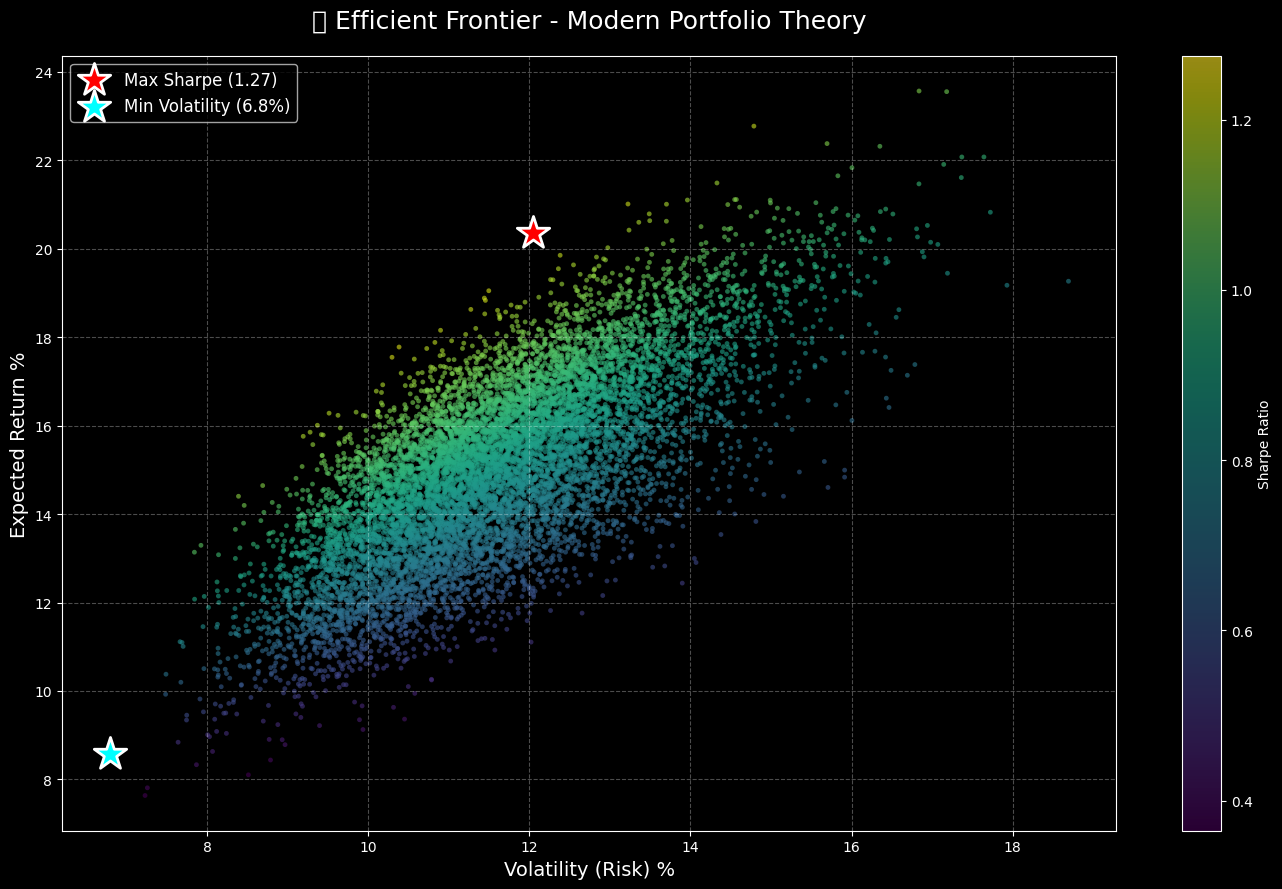


💾 Chart saved as 'efficient_frontier.png'


In [17]:
# Create the Efficient Frontier visualization
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(14, 9))

# Scatter plot of all portfolios (color by Sharpe)
scatter = ax.scatter(
    port_volatilities * 100,
    port_returns * 100,
    c=port_sharpes,
    cmap='viridis',
    marker='o',
    s=12,
    alpha=0.6,
    edgecolors='none'
)

# Mark Max Sharpe portfolio
ax.scatter(
    port_volatilities[max_sharpe_idx] * 100,
    port_returns[max_sharpe_idx] * 100,
    marker='*',
    color='red',
    s=600,
    edgecolors='white',
    linewidths=2,
    label=f'Max Sharpe ({port_sharpes[max_sharpe_idx]:.2f})',
    zorder=5
)

# Mark Min Volatility portfolio
ax.scatter(
    port_volatilities[min_vol_idx] * 100,
    port_returns[min_vol_idx] * 100,
    marker='*',
    color='cyan',
    s=600,
    edgecolors='white',
    linewidths=2,
    label=f'Min Volatility ({port_volatilities[min_vol_idx]*100:.1f}%)',
    zorder=5
)

# Colorbar
cbar = plt.colorbar(scatter, ax=ax, label='Sharpe Ratio')
cbar.ax.yaxis.label.set_color('white')
cbar.ax.tick_params(colors='white')

# Labels
ax.set_xlabel('Volatility (Risk) %', fontsize=14, color='white')
ax.set_ylabel('Expected Return %', fontsize=14, color='white')
ax.set_title('📈 Efficient Frontier - Modern Portfolio Theory', fontsize=18, color='white', pad=20)
ax.legend(loc='upper left', fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('efficient_frontier.png', dpi=150, bbox_inches='tight', facecolor='#1a1a1a')
plt.show()

print("\n💾 Chart saved as 'efficient_frontier.png'")

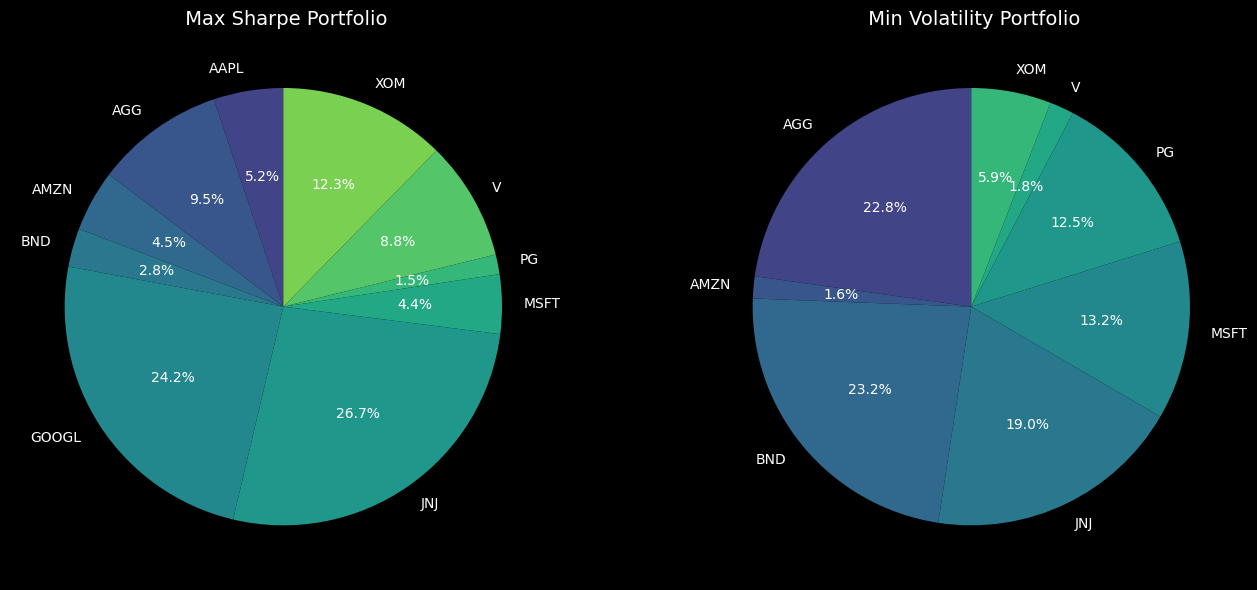

In [26]:
# Pie charts for portfolio allocations
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(actual_tickers)))

# Max Sharpe allocation
ax1 = axes[0]
filtered_ms = [(t, w) for t, w in zip(actual_tickers, max_sharpe_weights) if w > 0.01]
ax1.pie([w for _, w in filtered_ms], labels=[t for t, _ in filtered_ms], 
        autopct='%1.1f%%', colors=colors[:len(filtered_ms)], startangle=90)
ax1.set_title(' Max Sharpe Portfolio', fontsize=14)

# Min Volatility allocation
ax2 = axes[1]
filtered_mv = [(t, w) for t, w in zip(actual_tickers, min_vol_weights) if w > 0.01]
ax2.pie([w for _, w in filtered_mv], labels=[t for t, _ in filtered_mv],
        autopct='%1.1f%%', colors=colors[:len(filtered_mv)], startangle=90)
ax2.set_title(' Min Volatility Portfolio', fontsize=14)

plt.tight_layout()
plt.show()

---

# 9. Key Takeaways 🎓

### What You Learned:

1. **Data Fetching** - yfinance pulls real market data
2. **Log Returns** - $r = \ln(P_t/P_{t-1})$ - better for statistics  
3. **Covariance Matrix** - measures how stocks move together
4. **Portfolio Volatility** - NOT just weighted average (that's the magic!)
5. **Sharpe Ratio** - risk-adjusted performance metric
6. **Monte Carlo** - simulate thousands of scenarios to explore possibilities
7. **Efficient Frontier** - the optimal risk-return tradeoff

### The "Free Lunch" of Finance:
**Diversification reduces risk without reducing expected return!**

### Next Steps to Learn More:
- Add more stocks from different sectors
- Add constraints (e.g., max 30% in any stock)
- Use `scipy.optimize` for exact optimization
- Explore risk parity strategies

---

#  Challenge Exercise


**Question to think about:** Why might adding bonds improve your portfolio's Sharpe ratio?

**Hint:** Bonds often have low correlation with stocks, which can reduce overall portfolio volatility!

**Answer** :
Since bonds typically have lower volatility and a low correlation with stocks, adding them to a portfolio can reduce overall risk without significantly sacrificing returns. 
--
Since the Sharpe ratio is Reward ÷ Stress, if you lower the bottom number (stress) while keeping the top number (reward) mostly the same, the fraction gets bigger.



---

# ✅ Proof: Why Bonds Can Improve Sharpe Ratio

## 1) Mathematical proof (two-asset case: Stocks + Bonds)

Let:
- $w_s, w_b$ be portfolio weights with $w_s + w_b = 1$
- $\sigma_s, \sigma_b$ be volatilities
- $\rho_{sb}$ be stock-bond correlation
- $\mu_s, \mu_b$ be expected returns

Portfolio variance is:

$$
\sigma_p^2 = w_s^2\sigma_s^2 + w_b^2\sigma_b^2 + 2w_sw_b\rho_{sb}\sigma_s\sigma_b
$$

Compare with the square of weighted volatility sum:

$$
(w_s\sigma_s + w_b\sigma_b)^2 = w_s^2\sigma_s^2 + w_b^2\sigma_b^2 + 2w_sw_b\sigma_s\sigma_b
$$

Subtracting gives:

$$
(w_s\sigma_s + w_b\sigma_b)^2 - \sigma_p^2
= 2w_sw_b\sigma_s\sigma_b(1-\rho_{sb})
$$

If $\rho_{sb} < 1$ and $w_s, w_b > 0$, the RHS is positive, so

$$
\sigma_p < w_s\sigma_s + w_b\sigma_b
$$

So adding bonds with less-than-perfect correlation reduces risk through diversification.

Sharpe ratio is $S = (\mu - r_f)/\sigma$.
If return does not fall "too much" while $\sigma$ falls, Sharpe increases.

Next cells verify this numerically on your own dataset.

---

#  ADVANCED: Rolling Window Backtest

## Why This Matters

Everything above is **in-sample optimization** — you optimize on data, then evaluate on the SAME data. That's cheating!

**The problem:** Your 93% GOOGL allocation worked from 2024-2025. But would you have known to pick GOOGL in January 2024? No. You're using future information.

**The solution:** Rolling window backtest
1. Train on past data (e.g., 12 months)
2. Optimize portfolio
3. Test on NEXT period (e.g., 1 month)  
4. Roll forward and repeat (Shift → train → test)

This simulates what you'd actually experience as an investor.

In [19]:
# Fetch MORE data for proper backtesting (need history before 2024)

print("📥 Fetching extended data for backtesting...")
backtest_prices = fetch_stock_data(TICKERS, '2022-01-01', '2026-01-01')
backtest_returns = calculate_log_returns(backtest_prices)

print(f"✅ Loaded {len(backtest_prices)} trading days")
print(f"   Date range: {backtest_prices.index[0].strftime('%Y-%m-%d')} to {backtest_prices.index[-1].strftime('%Y-%m-%d')}")

📥 Fetching extended data for backtesting...
✅ Loaded 1003 trading days
   Date range: 2022-01-03 to 2025-12-31


In [20]:
def find_max_sharpe_portfolio(returns, rf_rate=0.05, n_simulations=5000):
    """Find max Sharpe portfolio using vectorized Monte Carlo."""
    n_assets = returns.shape[1]

    # Calculate statistics from this window
    exp_ret = (returns.mean() * 252).values
    cov = (returns.cov() * 252).values

    raw_weights = np.random.random((n_simulations, n_assets))
    weights = raw_weights / raw_weights.sum(axis=1, keepdims=True)

    portfolio_returns = weights @ exp_ret
    portfolio_variances = np.einsum('ij,jk,ik->i', weights, cov, weights)
    portfolio_vols = np.sqrt(portfolio_variances)

    sharpe = np.where(
        portfolio_vols > 1e-12,
        (portfolio_returns - rf_rate) / portfolio_vols,
        -np.inf
    )

    best_idx = np.argmax(sharpe)
    return weights[best_idx], sharpe[best_idx]


def find_min_vol_portfolio(returns, n_simulations=5000):
    """Find minimum volatility portfolio using vectorized Monte Carlo."""
    n_assets = returns.shape[1]
    cov = (returns.cov() * 252).values

    raw_weights = np.random.random((n_simulations, n_assets))
    weights = raw_weights / raw_weights.sum(axis=1, keepdims=True)

    portfolio_variances = np.einsum('ij,jk,ik->i', weights, cov, weights)
    portfolio_vols = np.sqrt(portfolio_variances)

    best_idx = np.argmin(portfolio_vols)
    return weights[best_idx], portfolio_vols[best_idx]

In [21]:
def rolling_backtest(returns, lookback_days=252, rebalance_days=21):
    """
    Rolling window backtest.
    
    Parameters:
    -----------
    returns : DataFrame of daily returns
    lookback_days : Days of history to use for optimization (default 1 year)
    rebalance_days : Days to hold before rebalancing (default ~1 month)
    
    Returns:
    --------
    DataFrame with daily portfolio returns for each strategy
    """
    
    results = {
        'max_sharpe': [],
        'min_vol': [],
        'equal_weight': [],
        'dates': []
    }
    
    n_assets = returns.shape[1]
    equal_weights = np.ones(n_assets) / n_assets
    
    # Current weights (start with equal)
    ms_weights = equal_weights.copy()
    mv_weights = equal_weights.copy()
    
    days_since_rebalance = rebalance_days  # Force rebalance on first valid day
    
    for i in range(lookback_days, len(returns)):
        # Check if we need to rebalance
        if days_since_rebalance >= rebalance_days:
            # Get training window
            train_returns = returns.iloc[i-lookback_days:i]
            
            # Optimize portfolios on training data
            ms_weights, _ = find_max_sharpe_portfolio(train_returns)
            mv_weights, _ = find_min_vol_portfolio(train_returns)
            
            days_since_rebalance = 0
        
        # Get today's returns
        today_returns = returns.iloc[i].values
        
        # Calculate portfolio returns (out-of-sample!)
        ms_ret = np.dot(ms_weights, today_returns)
        mv_ret = np.dot(mv_weights, today_returns)
        eq_ret = np.dot(equal_weights, today_returns)
        
        results['max_sharpe'].append(ms_ret)
        results['min_vol'].append(mv_ret)
        results['equal_weight'].append(eq_ret)
        results['dates'].append(returns.index[i])
        
        days_since_rebalance += 1
    
    return pd.DataFrame(results).set_index('dates')

In [22]:
%%time
print("🔄 Running rolling window backtest...")
print("   Lookback: 252 days (1 year)")
print("   Rebalance: Every 21 days (~monthly)")
print("   This simulates REAL investing - using only past data!\n")

# Run the backtest
backtest_results = rolling_backtest(backtest_returns, lookback_days=252, rebalance_days=21)

print(f"✅ Backtest complete!")
print(f"   Test period: {backtest_results.index[0].strftime('%Y-%m-%d')} to {backtest_results.index[-1].strftime('%Y-%m-%d')}")
print(f"   Trading days tested: {len(backtest_results)}")

🔄 Running rolling window backtest...
   Lookback: 252 days (1 year)
   Rebalance: Every 21 days (~monthly)
   This simulates REAL investing - using only past data!

✅ Backtest complete!
   Test period: 2023-01-05 to 2025-12-31
   Trading days tested: 750
CPU times: total: 141 ms
Wall time: 159 ms


In [32]:
# Calculate cumulative returns (wealth growth)
cumulative = (1 + backtest_results).cumprod()

# Calculate performance metrics
def calc_metrics(returns, rf_rate=0.05):
    """Calculate key performance metrics."""
    annual_ret = returns.mean() * 252
    annual_vol = returns.std() * np.sqrt(252)
    sharpe = (annual_ret - rf_rate) / annual_vol
    
    # Maximum drawdown
    cumulative = (1 + returns).cumprod()
    running_max = cumulative.cummax()
    drawdown = (cumulative - running_max) / running_max
    max_dd = drawdown.min()
    
    return {
        'Annual Return': annual_ret,
        'Annual Volatility': annual_vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_dd
    }

# Calculate metrics for each strategy
metrics = {}
for strategy in ['max_sharpe', 'min_vol', 'equal_weight']:
    metrics[strategy] = calc_metrics(backtest_results[strategy])

# Display comparison

print(f"\n{'Strategy':<15} {'Return':>12} {'Volatility':>12} {'Sharpe':>10} {'Max DD':>12}")
print("-" * 70)
for strategy, m in metrics.items():
    print(f"{strategy:<15} {m['Annual Return']:>11.1%} {m['Annual Volatility']:>11.1%} {m['Sharpe Ratio']:>10.2f} {m['Max Drawdown']:>11.1%}")
print("=" * 70)


Strategy              Return   Volatility     Sharpe       Max DD
----------------------------------------------------------------------
max_sharpe            10.7%       13.4%       0.42      -20.8%
min_vol                8.5%        7.3%       0.49       -7.4%
equal_weight          17.0%       11.1%       1.08      -13.3%


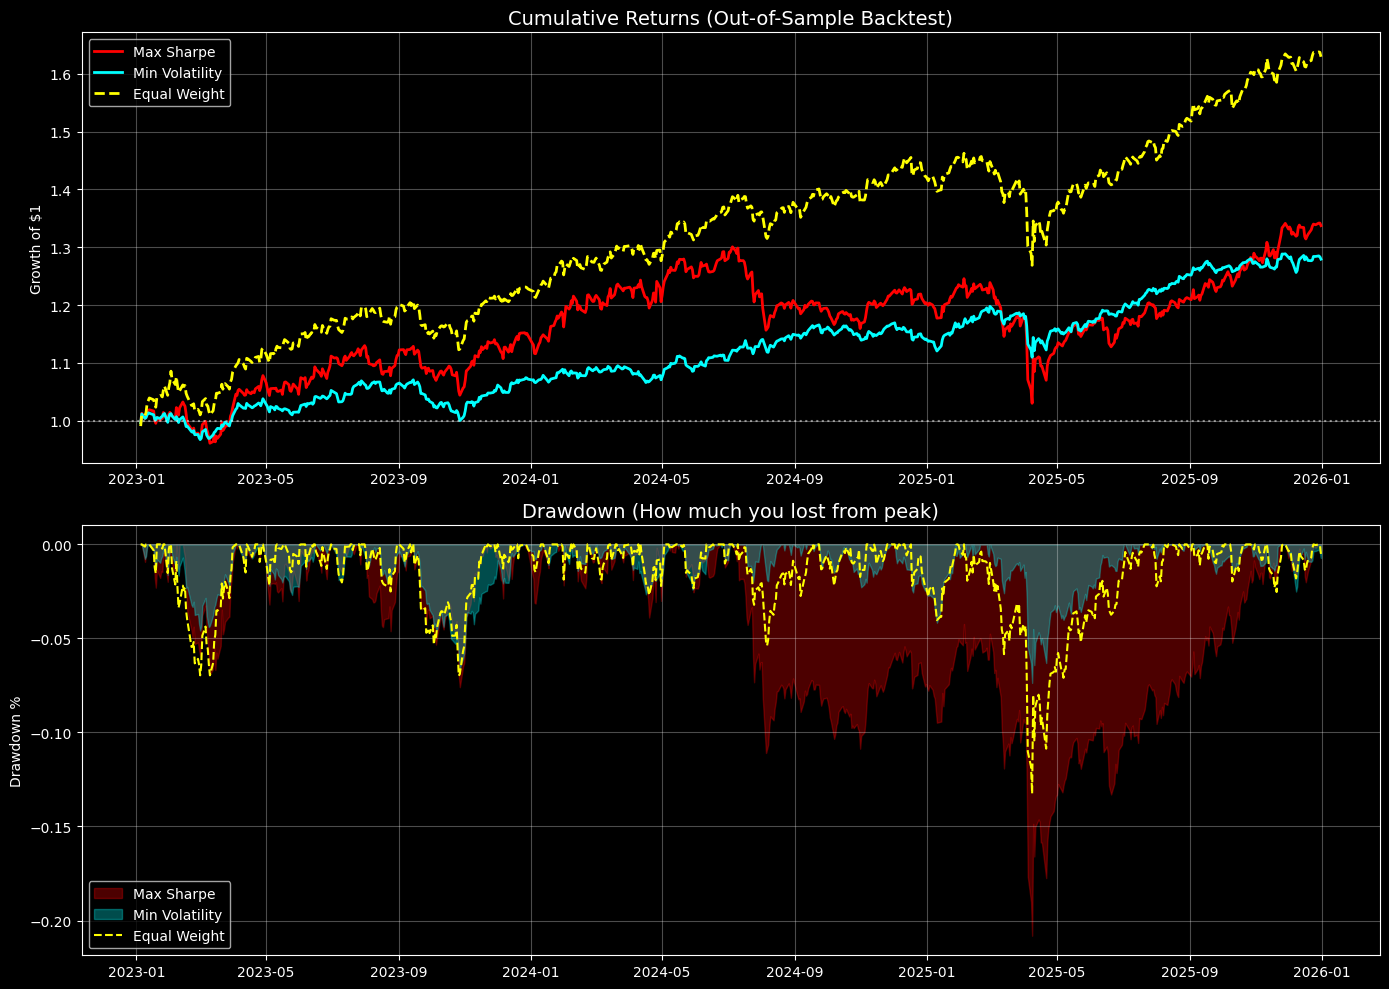

In [33]:
# Visualize cumulative returns
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Cumulative returns (wealth growth)
ax1 = axes[0]
ax1.plot(cumulative.index, cumulative['max_sharpe'], label='Max Sharpe', linewidth=2, color='red')
ax1.plot(cumulative.index, cumulative['min_vol'], label='Min Volatility', linewidth=2, color='cyan')
ax1.plot(cumulative.index, cumulative['equal_weight'], label='Equal Weight', linewidth=2, color='yellow', linestyle='--')
ax1.set_title('Cumulative Returns (Out-of-Sample Backtest)', fontsize=14)
ax1.set_ylabel('Growth of $1')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=1, color='white', linestyle=':', alpha=0.5)

# Plot 2: Drawdown
running_max = cumulative.cummax()
drawdown = (cumulative - running_max) / running_max

ax2 = axes[1]
ax2.fill_between(drawdown.index, drawdown['max_sharpe'], 0, alpha=0.3, color='red', label='Max Sharpe')
ax2.fill_between(drawdown.index, drawdown['min_vol'], 0, alpha=0.3, color='cyan', label='Min Volatility')
ax2.plot(drawdown.index, drawdown['equal_weight'], color='yellow', linestyle='--', label='Equal Weight')
ax2.set_title('Drawdown (How much you lost from peak)', fontsize=14)
ax2.set_ylabel('Drawdown %')
ax2.legend(loc='lower left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 🎯 Key Insights from Backtesting

### What You Should Notice:

1. **Sharpe ratios are LOWER** than in-sample optimization
   - In-sample Sharpe ≈ 1.2 → Out-of-sample likely < 1.0
   - This is **estimation error** — the biggest problem in MPT

2. **Equal Weight often competes well**
   - Simple strategies are robust because they don't overfit
   - This is called the "1/N puzzle" in academic finance

3. **Max Sharpe may NOT beat Min Volatility**
   - Expected returns are hard to estimate
   - Volatility estimates are more stable
   - "Risk is more predictable than return"

4. **Drawdowns matter**
   - High Sharpe doesn't mean low drawdown
   - Real investors feel losses more than gains

### The Brutal Truth:
> **In-sample optimization is an illusion.** Out-of-sample is reality.

This is why hedge funds spend millions on robust optimization, not basic Markowitz.

In [25]:
# Compare In-Sample vs Out-of-Sample
print("=" * 70)
print("⚠️  IN-SAMPLE vs OUT-OF-SAMPLE COMPARISON")
print("=" * 70)

# In-sample metrics (from earlier optimization)
in_sample_sharpe = port_sharpes[max_sharpe_idx]
out_sample_sharpe = metrics['max_sharpe']['Sharpe Ratio']

print(f"\nMax Sharpe Portfolio:")
print(f"  In-Sample Sharpe:  {in_sample_sharpe:.2f}  ← Optimized on full data")
print(f"  Out-Sample Sharpe: {out_sample_sharpe:.2f}  ← Tested on unseen data")
print(f"  Degradation:       {((out_sample_sharpe / in_sample_sharpe) - 1) * 100:.0f}%")

print(f"""
💡 This gap is called "OVERFITTING" or "ESTIMATION ERROR"

The in-sample portfolio looked amazing because it was
optimized on the SAME data it was tested on.

Out-of-sample shows what you'd ACTUALLY experience.
""")

⚠️  IN-SAMPLE vs OUT-OF-SAMPLE COMPARISON

Max Sharpe Portfolio:
  In-Sample Sharpe:  1.27  ← Optimized on full data
  Out-Sample Sharpe: 0.42  ← Tested on unseen data
  Degradation:       -67%

💡 This gap is called "OVERFITTING" or "ESTIMATION ERROR"

The in-sample portfolio looked amazing because it was
optimized on the SAME data it was tested on.

Out-of-sample shows what you'd ACTUALLY experience.



---

# Your Learning Roadmap

| Step | Topic | Why It Matters | Status |
|------|-------|----------------|--------|
| 1 | **Markowitz MPT** | Foundation - portfolio math | Done |
| 1b | **Rolling Backtest** | Reality of estimation error | Done |
| 2 | **CAPM & Beta** | Market risk vs alpha | Done |
| 3 | **Convex Optimization** | Exact solutions with constraints | Done |
| 4 | **Risk Metrics** | VaR, CVaR, Sortino, Drawdown | Done |
| 5 | **Factor Models** | Fama-French, why stocks co-move | Next |
| 6 | **Black-Litterman** | Fix MPT instability with Bayesian views | |

**Big insight you should have now:**
> "Optimizing a portfolio is easy. Optimizing it *robustly* is the hard part."

---

# 📘 Step 2: CAPM & Beta

Now we move from pure mean-variance intuition to a market-risk model.

## CAPM formula

$$
\mathbb{E}[R_i] = R_f + \beta_i\big(\mathbb{E}[R_m] - R_f\big)
$$

Where:
- $R_f$: risk-free rate
- $R_m$: market return (we will use SPY as a proxy)
- $\beta_i$: sensitivity of asset $i$ to market movements

## Beta from data

$$
\beta_i = \frac{\mathrm{Cov}(R_i, R_m)}{\mathrm{Var}(R_m)}
$$

Interpretation:
- $\beta > 1$: more volatile than market
- $\beta < 1$: defensive asset
- $\beta < 0$: tends to move opposite to market (rare for equities, possible for hedges)

In [36]:
# Get market benchmark returns (SPY) aligned to our sample
MARKET_TICKER = 'SPY'

market_data = yf.download(MARKET_TICKER, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)
market_close = market_data['Close']

# yfinance can return either Series or single-column DataFrame
if isinstance(market_close, pd.DataFrame):
    market_prices = market_close.iloc[:, 0].dropna()
else:
    market_prices = market_close.dropna()

market_returns = np.log(market_prices).diff().dropna()
market_returns.name = 'MARKET'

# Align asset and market returns on common dates
aligned = daily_returns.join(market_returns, how='inner').dropna()

print(f"✅ Market proxy: {MARKET_TICKER}")
print(f"✅ Aligned observations: {len(aligned)}")
print(f"📅 Date range: {aligned.index[0].date()} to {aligned.index[-1].date()}")

✅ Market proxy: SPY
✅ Aligned observations: 501
📅 Date range: 2024-01-03 to 2025-12-31


In [37]:
# Estimate Beta, Alpha, and R^2 for each asset
market_var = aligned['MARKET'].var()
market_annual_return = aligned['MARKET'].mean() * TRADING_DAYS

capm_rows = []
for t in actual_tickers:
    ri = aligned[t]
    rm = aligned['MARKET']

    # Beta via covariance/variance
    beta = ri.cov(rm) / market_var

    # OLS regression: ri = alpha_daily + beta * rm + error
    X = np.column_stack([np.ones(len(rm)), rm.values])
    y = ri.values
    coef = np.linalg.lstsq(X, y, rcond=None)[0]
    alpha_daily, beta_ols = coef[0], coef[1]

    y_hat = X @ coef
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    alpha_annual = alpha_daily * TRADING_DAYS
    capm_expected = RISK_FREE_RATE + beta * (market_annual_return - RISK_FREE_RATE)

    capm_rows.append({
        'Ticker': t,
        'Beta': beta,
        'Beta_OLS': beta_ols,
        'Alpha_annual': alpha_annual,
        'R2': r2,
        'Historical_return': annual_returns[t],
        'CAPM_expected_return': capm_expected,
        'Return_gap(Historical-CAPM)': annual_returns[t] - capm_expected
    })

capm_df = pd.DataFrame(capm_rows).set_index('Ticker').sort_values('Beta')

print("📊 CAPM & BETA SUMMARY")
display_cols = ['Beta', 'Alpha_annual', 'R2', 'Historical_return', 'CAPM_expected_return', 'Return_gap(Historical-CAPM)']
display(capm_df[display_cols].round(4))

📊 CAPM & BETA SUMMARY


,Beta,Alpha_annual,R2,Historical_return,CAPM_expected_return,Return_gap(Historical-CAPM)
Ticker,,,,,,
JNJ,0.0263,0.1552,0.0006,0.1604,0.0539,0.1065
BND,0.0337,0.0368,0.0123,0.0435,0.0549,-0.0115
AGG,0.0365,0.0367,0.0140,0.0439,0.0554,-0.0115
PG,0.1036,-0.0136,0.0097,0.0068,0.0652,-0.0584
XOM,0.4300,0.0318,0.1067,0.1164,0.1131,0.0033
V,0.7091,0.0207,0.3358,0.1601,0.1540,0.0061
MSFT,0.9656,-0.0489,0.5062,0.1410,0.1916,-0.0507
GOOGL,1.0938,0.2000,0.3491,0.4151,0.2104,0.2047
AAPL,1.1596,-0.0314,0.4655,0.1966,0.2201,-0.0235


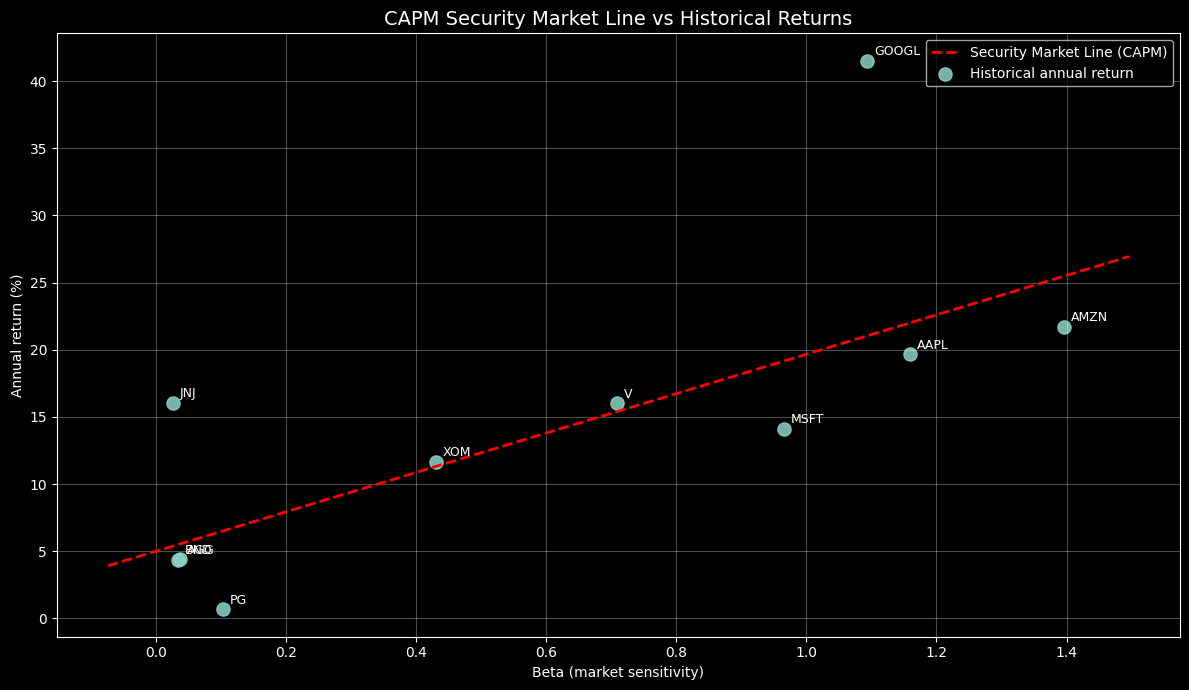

In [38]:
# Security Market Line (SML): CAPM expected return vs beta
beta_grid = np.linspace(capm_df['Beta'].min() - 0.1, capm_df['Beta'].max() + 0.1, 100)
sml = RISK_FREE_RATE + beta_grid * (market_annual_return - RISK_FREE_RATE)

plt.figure(figsize=(12, 7))
plt.plot(beta_grid, sml * 100, 'r--', linewidth=2, label='Security Market Line (CAPM)')

plt.scatter(
    capm_df['Beta'],
    capm_df['Historical_return'] * 100,
    s=90,
    alpha=0.85,
    label='Historical annual return'
  )

for t in capm_df.index:
    plt.annotate(t, (capm_df.loc[t, 'Beta'], capm_df.loc[t, 'Historical_return'] * 100), xytext=(5, 4), textcoords='offset points', fontsize=9)

plt.title('CAPM Security Market Line vs Historical Returns', fontsize=14)
plt.xlabel('Beta (market sensitivity)')
plt.ylabel('Annual return (%)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [39]:
# Portfolio beta: equal-weight, max Sharpe, and min volatility portfolios
beta_vec = capm_df.loc[actual_tickers, 'Beta'].values

beta_equal = np.dot(equal_weights, beta_vec)
beta_max_sharpe = np.dot(max_sharpe_weights, beta_vec)
beta_min_vol = np.dot(min_vol_weights, beta_vec)

print('📌 PORTFOLIO BETAS')
print(f'   Equal-weight beta:   {beta_equal:.3f}')
print(f'   Max Sharpe beta:     {beta_max_sharpe:.3f}')
print(f'   Min Volatility beta: {beta_min_vol:.3f}')

print('\n💡 Interpretation:')
print('   - Beta > 1: portfolio tends to amplify market moves')
print('   - Beta < 1: portfolio tends to be more defensive than market')

📌 PORTFOLIO BETAS
   Equal-weight beta:   0.595
   Max Sharpe beta:     0.559
   Min Volatility beta: 0.230

💡 Interpretation:
   - Beta > 1: portfolio tends to amplify market moves
   - Beta < 1: portfolio tends to be more defensive than market


---

# Step 3: Convex Optimization (Exact Solutions)

## Why Move Beyond Monte Carlo?

Monte Carlo is great for **exploring** the space, but it has a fundamental problem:

With 10 assets, the weight space is 9-dimensional (weights must sum to 1). Throwing 10,000 random darts into a 9D space covers almost nothing. Your "optimal" portfolio from Monte Carlo is the **best of what you randomly tried**, not the true optimum.

**Convex optimization** uses calculus (gradients) to walk directly to the optimal point -- like using GPS instead of wandering randomly.

## The Key Idea

We already have these functions:
- `portfolio_return(weights, expected_returns)` → what we want to maximize
- `portfolio_volatility(weights, cov_matrix)` → what we want to minimize

`scipy.optimize.minimize` takes a function and finds the weights that minimize it, subject to **constraints**:
1. Weights must sum to 1 (fully invested)
2. Each weight between 0 and 1 (long-only, no short selling)
3. Optional: max 30% in any single stock (diversification rule)

## Why "Minimize" for Max Sharpe?

To **maximize** Sharpe, we **minimize negative Sharpe**. This is a standard trick:
$$\max f(x) = \min(-f(x))$$

In [ ]:
from scipy.optimize import minimize

def optimize_max_sharpe(expected_returns, cov_matrix, rf_rate=0.05):
    """
    Find the portfolio with the HIGHEST Sharpe ratio using exact optimization.
    
    How it works:
    1. Start from equal weights (a reasonable guess)
    2. scipy tries small changes to weights
    3. It follows the gradient (slope) toward better Sharpe
    4. Constraints ensure weights stay valid
    """
    n_assets = len(expected_returns)
    
    # Objective: MINIMIZE negative Sharpe (= maximize Sharpe)
    def neg_sharpe(weights):
        ret = np.dot(weights, expected_returns)
        vol = np.sqrt(np.dot(weights, np.dot(cov_matrix, weights)))
        return -(ret - rf_rate) / vol
    
    # Constraints
    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}  # weights sum to 1
    ]
    
    # Bounds: each weight between 0% and 100% (long-only)
    bounds = tuple((0, 1) for _ in range(n_assets))
    
    # Start from equal weights
    initial_weights = np.ones(n_assets) / n_assets
    
    result = minimize(
        neg_sharpe,
        initial_weights,
        method='SLSQP',        # Sequential Least Squares Programming
        bounds=bounds,
        constraints=constraints,
        options={'maxiter': 1000, 'ftol': 1e-12}
    )
    
    return result.x, -result.fun  # return weights and Sharpe (flip sign back)


def optimize_min_volatility(expected_returns, cov_matrix):
    """Find the portfolio with the LOWEST volatility."""
    n_assets = len(expected_returns)
    
    def port_vol(weights):
        return np.sqrt(np.dot(weights, np.dot(cov_matrix, weights)))
    
    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
    ]
    bounds = tuple((0, 1) for _ in range(n_assets))
    initial_weights = np.ones(n_assets) / n_assets
    
    result = minimize(
        port_vol,
        initial_weights,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'maxiter': 1000, 'ftol': 1e-12}
    )
    
    return result.x, result.fun


print("✅ Optimization functions defined")
print("   optimize_max_sharpe()  → finds best risk-adjusted portfolio")
print("   optimize_min_volatility() → finds safest portfolio")

In [ ]:
# Run the optimizer and compare with Monte Carlo results
opt_ms_weights, opt_ms_sharpe = optimize_max_sharpe(exp_ret_array, cov_array, RISK_FREE_RATE)
opt_mv_weights, opt_mv_vol = optimize_min_volatility(exp_ret_array, cov_array)

# Calculate full stats for optimized portfolios
opt_ms_ret = portfolio_return(opt_ms_weights, exp_ret_array)
opt_ms_vol = portfolio_volatility(opt_ms_weights, cov_array)

opt_mv_ret = portfolio_return(opt_mv_weights, exp_ret_array)
opt_mv_sharpe = (opt_mv_ret - RISK_FREE_RATE) / opt_mv_vol

print("=" * 65)
print("SCIPY OPTIMIZATION vs MONTE CARLO COMPARISON")
print("=" * 65)

print(f"\n{'MAX SHARPE PORTFOLIO':<30} {'Monte Carlo':>15} {'Scipy':>15}")
print("-" * 65)
print(f"{'  Sharpe Ratio':<30} {port_sharpes[max_sharpe_idx]:>15.4f} {opt_ms_sharpe:>15.4f}")
print(f"{'  Expected Return':<30} {port_returns[max_sharpe_idx]:>14.2%} {opt_ms_ret:>14.2%}")
print(f"{'  Volatility':<30} {port_volatilities[max_sharpe_idx]:>14.2%} {opt_ms_vol:>14.2%}")

print(f"\n{'MIN VOLATILITY PORTFOLIO':<30} {'Monte Carlo':>15} {'Scipy':>15}")
print("-" * 65)
print(f"{'  Volatility':<30} {port_volatilities[min_vol_idx]:>14.2%} {opt_mv_vol:>14.2%}")
print(f"{'  Expected Return':<30} {port_returns[min_vol_idx]:>14.2%} {opt_mv_ret:>14.2%}")
print(f"{'  Sharpe Ratio':<30} {port_sharpes[min_vol_idx]:>15.4f} {opt_mv_sharpe:>15.4f}")

print(f"""
💡 KEY INSIGHT:
   Scipy finds a BETTER Sharpe than Monte Carlo because it searches
   precisely instead of randomly. The improvement may look small, but
   in finance even 0.01 Sharpe improvement matters at scale.
   
   Monte Carlo: explored {N_PORTFOLIOS:,} random portfolios
   Scipy: found the exact optimum in milliseconds
""")

In [ ]:
# Show the optimized allocations
print("=" * 60)
print("OPTIMIZED MAX SHARPE ALLOCATION")
print("=" * 60)
for ticker, weight in zip(actual_tickers, opt_ms_weights):
    if weight > 0.001:
        bar = "█" * int(weight * 40)
        print(f"  {ticker:5} {weight:6.1%} {bar}")

print(f"\n{'=' * 60}")
print("OPTIMIZED MIN VOLATILITY ALLOCATION")
print("=" * 60)
for ticker, weight in zip(actual_tickers, opt_mv_weights):
    if weight > 0.001:
        bar = "█" * int(weight * 40)
        print(f"  {ticker:5} {weight:6.1%} {bar}")

print("""
💡 NOTICE:
   The optimizer often puts MOST weight into very few assets.
   This is a known weakness of Markowitz optimization -- it's
   very sensitive to small changes in expected returns.
   This is exactly what Black-Litterman (a future step) fixes.
""")

## Adding Real-World Constraints

The optimizer above concentrates into few stocks. In practice, fund managers add rules like:
- **Max weight per stock**: no more than 30% in any single name (diversification)
- **Min weight**: at least 2% in each stock (ensures broad exposure)
- **Sector limits**: no more than 50% in tech, etc.

The beauty of `scipy.optimize` is that adding these constraints is just one line of code -- try doing that with Monte Carlo!

In [ ]:
def optimize_max_sharpe_constrained(expected_returns, cov_matrix, rf_rate=0.05,
                                    max_weight=0.30, min_weight=0.02):
    """
    Max Sharpe with diversification constraints.
    
    Only change vs unconstrained: the bounds parameter!
    Before: (0, 1)      → any weight from 0% to 100%
    Now:    (0.02, 0.30) → between 2% and 30% per stock
    """
    n_assets = len(expected_returns)
    
    def neg_sharpe(weights):
        ret = np.dot(weights, expected_returns)
        vol = np.sqrt(np.dot(weights, np.dot(cov_matrix, weights)))
        return -(ret - rf_rate) / vol
    
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    
    # THIS IS THE ONLY CHANGE: tighter bounds
    bounds = tuple((min_weight, max_weight) for _ in range(n_assets))
    
    initial_weights = np.ones(n_assets) / n_assets
    
    result = minimize(neg_sharpe, initial_weights, method='SLSQP',
                      bounds=bounds, constraints=constraints,
                      options={'maxiter': 1000, 'ftol': 1e-12})
    
    return result.x, -result.fun

# Run constrained optimization
con_weights, con_sharpe = optimize_max_sharpe_constrained(
    exp_ret_array, cov_array, RISK_FREE_RATE, max_weight=0.30, min_weight=0.02
)
con_ret = portfolio_return(con_weights, exp_ret_array)
con_vol = portfolio_volatility(con_weights, cov_array)

print("=" * 60)
print("CONSTRAINED MAX SHARPE (2%-30% per stock)")
print("=" * 60)
print(f"  Sharpe: {con_sharpe:.4f}  |  Return: {con_ret:.2%}  |  Vol: {con_vol:.2%}")
print()
for ticker, weight in zip(actual_tickers, con_weights):
    bar = "█" * int(weight * 40)
    print(f"  {ticker:5} {weight:6.1%} {bar}")

print(f"""
💡 Compare with unconstrained Sharpe: {opt_ms_sharpe:.4f}
   Constrained Sharpe:               {con_sharpe:.4f}
   
   You lose a bit of Sharpe, but gain a much more diversified
   and realistic portfolio. This tradeoff is worth it in practice.
""")

## Tracing the Exact Efficient Frontier

With Monte Carlo we got a "cloud" of dots. With scipy we can trace the **exact** efficient frontier curve by solving a series of optimization problems:

For each target return level, find the **minimum volatility** portfolio that achieves at least that return. Connect the dots → exact frontier.

In [ ]:
def trace_efficient_frontier(expected_returns, cov_matrix, n_points=50):
    """
    Trace the exact efficient frontier by solving:
    'For each target return, what is the minimum volatility portfolio?'
    """
    n_assets = len(expected_returns)
    
    # Range of target returns: from min-vol return to max possible return
    # (max possible = 100% in highest-returning asset)
    min_ret = optimize_min_volatility(expected_returns, cov_matrix)
    min_ret_val = np.dot(min_ret[0], expected_returns)
    max_ret_val = expected_returns.max()
    
    target_returns = np.linspace(min_ret_val, max_ret_val, n_points)
    frontier_vols = []
    frontier_rets = []
    
    for target in target_returns:
        def port_vol(weights):
            return np.sqrt(np.dot(weights, np.dot(cov_matrix, weights)))
        
        constraints = [
            {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
            {'type': 'eq', 'fun': lambda w, t=target: np.dot(w, expected_returns) - t}
        ]
        bounds = tuple((0, 1) for _ in range(n_assets))
        initial = np.ones(n_assets) / n_assets
        
        result = minimize(port_vol, initial, method='SLSQP',
                         bounds=bounds, constraints=constraints,
                         options={'maxiter': 1000, 'ftol': 1e-12})
        
        if result.success:
            frontier_vols.append(result.fun)
            frontier_rets.append(target)
    
    return np.array(frontier_vols), np.array(frontier_rets)


# Trace the frontier
print("Tracing exact efficient frontier...")
frontier_vols, frontier_rets = trace_efficient_frontier(exp_ret_array, cov_array)
print(f"✅ Traced {len(frontier_vols)} points on the efficient frontier")

In [ ]:
# Plot: Monte Carlo cloud + exact efficient frontier + optimized portfolios
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(14, 9))

# Monte Carlo cloud
scatter = ax.scatter(
    port_volatilities * 100, port_returns * 100,
    c=port_sharpes, cmap='viridis', marker='o', s=10, alpha=0.4, edgecolors='none'
)

# Exact efficient frontier (the key addition!)
ax.plot(frontier_vols * 100, frontier_rets * 100,
        color='white', linewidth=3, label='Exact Efficient Frontier (scipy)', zorder=4)

# Monte Carlo "best" portfolios
ax.scatter(port_volatilities[max_sharpe_idx] * 100, port_returns[max_sharpe_idx] * 100,
           marker='o', color='red', s=200, edgecolors='white', linewidths=2,
           label=f'MC Max Sharpe ({port_sharpes[max_sharpe_idx]:.3f})', zorder=5)

# Scipy optimized portfolios
ax.scatter(opt_ms_vol * 100, opt_ms_ret * 100,
           marker='*', color='red', s=600, edgecolors='white', linewidths=2,
           label=f'Scipy Max Sharpe ({opt_ms_sharpe:.3f})', zorder=6)

ax.scatter(opt_mv_vol * 100, opt_mv_ret * 100,
           marker='*', color='cyan', s=600, edgecolors='white', linewidths=2,
           label=f'Scipy Min Vol ({opt_mv_vol*100:.1f}%)', zorder=6)

# Constrained portfolio
ax.scatter(con_vol * 100, con_ret * 100,
           marker='D', color='lime', s=200, edgecolors='white', linewidths=2,
           label=f'Constrained Max Sharpe ({con_sharpe:.3f})', zorder=6)

plt.colorbar(scatter, ax=ax, label='Sharpe Ratio')
ax.set_title('Efficient Frontier: Monte Carlo vs Exact Optimization', fontsize=16)
ax.set_xlabel('Volatility (%)', fontsize=12)
ax.set_ylabel('Expected Return (%)', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 3 Takeaways

### What you learned:
1. **`scipy.optimize.minimize`** finds exact optimal portfolios instead of random guessing
2. **Constraints are easy to add** -- just change bounds or add constraint functions
3. **The exact efficient frontier** is a clean curve, not a fuzzy cloud
4. **Unconstrained optimization concentrates** into few stocks -- constraints make portfolios realistic
5. **The "minimize negative" trick** lets you maximize any objective function

### The pattern for any optimization problem:
```
1. Define objective function  (what to minimize)
2. Define constraints         (what rules to follow)
3. Define bounds              (what range for each variable)
4. Call scipy.optimize.minimize
```

### What's still broken?
The optimizer is only as good as its **inputs** (expected returns and covariance). Small errors in expected returns → wildly different portfolios. This instability is the #1 practical problem with Markowitz optimization.

**Next steps to explore:**
- **Risk metrics (VaR, CVaR, Sortino)** -- better ways to measure risk beyond volatility
- **Factor models (Fama-French)** -- understand WHY stocks move together
- **Black-Litterman** -- fix the input instability problem with Bayesian statistics

---

# Step 4: Risk Metrics -- Beyond Volatility

## Why Volatility Is Not Enough

So far we've measured risk with **volatility** (standard deviation of returns). But volatility has a big blind spot:

**It treats upside and downside equally.** A stock that jumps +10% is "risky" by the same amount as one that drops -10%. But as an investor, you don't mind upside surprises -- you only fear the downside.

## The Metrics We'll Learn

| Metric | What It Measures | Plain English |
|--------|-----------------|---------------|
| **VaR** (Value at Risk) | Worst expected loss at a confidence level | "On 95% of days, I won't lose more than X%" |
| **CVaR** (Conditional VaR) | Average loss when things go REALLY bad | "When I DO lose big, how bad is it on average?" |
| **Sortino Ratio** | Return per unit of *downside* risk only | "Like Sharpe, but ignores upside volatility" |
| **Max Drawdown** | Largest peak-to-trough decline | "The worst losing streak from peak to bottom" |

### Why This Matters In Practice

In 2008, many portfolios had "acceptable" volatility but experienced -50% drawdowns. Volatility didn't warn you. CVaR and Max Drawdown would have.

> **"Volatility is a statistician's measure of risk. Drawdown is an investor's measure of risk."**

## 4.1 Value at Risk (VaR)

### The Idea

VaR answers: **"What is the worst I can expect to lose on a normal day?"**

At a 95% confidence level:
- Sort all your daily returns from worst to best
- Find the 5th percentile (the return that's worse than 95% of days)
- That number is your VaR

$$\text{VaR}_{95\%} = -\text{Percentile}(R, 5\%)$$

The negative sign makes VaR a positive number (a "loss amount").

### Example
If daily VaR(95%) = 1.5%, it means:
- On 95% of days, you lose less than 1.5%
- On ~1 out of 20 trading days, you could lose MORE than 1.5%

## 4.2 Conditional VaR (CVaR) -- also called Expected Shortfall

VaR tells you the **threshold**, but not how bad it gets **beyond** that threshold.

CVaR answers: **"When things go worse than VaR, how bad is it on average?"**

$$\text{CVaR}_{95\%} = -\mathbb{E}[R \mid R \leq -\text{VaR}_{95\%}]$$

CVaR is always worse (larger) than VaR. It captures **tail risk** -- the extreme losses that VaR ignores.

### Why CVaR > VaR in Practice
- Banks and regulators now prefer CVaR over VaR (Basel III moved to CVaR in 2023)
- VaR can be "gamed" -- you can have low VaR but catastrophic tail losses
- CVaR is **coherent** (a mathematical property meaning it behaves sensibly when combining portfolios)

In [ ]:
def calculate_var(returns, confidence=0.95):
    """
    Historical VaR: just the percentile of actual returns.
    
    Parameters:
        returns: Series or array of daily returns
        confidence: 0.95 means "95% of days are better than this"
    
    Returns:
        VaR as a positive number (loss amount)
    """
    # The (1 - confidence) percentile gives the cutoff
    # e.g., 5th percentile for 95% confidence
    var = -np.percentile(returns, (1 - confidence) * 100)
    return var


def calculate_cvar(returns, confidence=0.95):
    """
    Historical CVaR (Expected Shortfall):
    Average of all returns WORSE than the VaR threshold.
    
    This is the mean of the worst (1-confidence)% of days.
    """
    var = calculate_var(returns, confidence)
    # Select only the returns that are worse than -VaR
    tail_losses = returns[returns <= -var]
    cvar = -tail_losses.mean()
    return cvar


# Calculate VaR and CVaR for each individual stock
print("=" * 65)
print("VALUE AT RISK (VaR) & CONDITIONAL VaR (CVaR) -- 95% confidence")
print("=" * 65)
print(f"\n{'Ticker':<8} {'Daily VaR':>12} {'Daily CVaR':>12} {'Annual VaR':>12} {'Annual CVaR':>13}")
print("-" * 65)

for ticker in actual_tickers:
    stock_returns = daily_returns[ticker].values
    var_95 = calculate_var(stock_returns, 0.95)
    cvar_95 = calculate_cvar(stock_returns, 0.95)
    # Annualize: scale by sqrt(252) (same logic as volatility)
    annual_var = var_95 * np.sqrt(TRADING_DAYS)
    annual_cvar = cvar_95 * np.sqrt(TRADING_DAYS)
    print(f"{ticker:<8} {var_95:>11.2%} {cvar_95:>11.2%} {annual_var:>11.2%} {annual_cvar:>12.2%}")

print(f"""
💡 Reading this table:
   - Daily VaR 1.5% means: on 95% of days, you lose less than 1.5%
   - Daily CVaR 2.3% means: on the WORST 5% of days, you lose 2.3% on average
   - CVaR is always >= VaR (it measures the tail beyond VaR)
   - Compare BND/AGG (bonds) vs tech stocks -- bonds have much lower tail risk
""")

## 4.3 Sortino Ratio -- Sharpe's Smarter Cousin

### The Problem with Sharpe

Recall: $\text{Sharpe} = \frac{R_p - R_f}{\sigma_p}$

The denominator $\sigma_p$ is total volatility -- it penalizes both up AND down moves equally. But upside volatility is **good**!

### Sortino's Fix

Replace total volatility with **downside deviation** -- only the volatility of negative returns:

$$\text{Sortino} = \frac{R_p - R_f}{\sigma_{\text{downside}}}$$

Where downside deviation is:
$$\sigma_{\text{downside}} = \sqrt{\frac{1}{N}\sum_{r_t < 0} r_t^2}$$

### When Sortino > Sharpe (in value)
- The stock has **asymmetric** returns -- lots of small gains, few large drops
- This is what you WANT as an investor
- A high Sortino relative to Sharpe means the stock's volatility comes mostly from the upside

In [ ]:
def downside_deviation(returns, trading_days=252):
    """
    Calculate annualized downside deviation.
    Only considers negative returns -- ignores upside volatility.
    """
    negative_returns = returns[returns < 0]
    # Use the full count (not just negative days) for proper scaling
    downside_var = np.sum(negative_returns ** 2) / len(returns)
    return np.sqrt(downside_var * trading_days)


def sortino_ratio(returns, rf_rate=0.05, trading_days=252):
    """
    Sortino ratio: like Sharpe but only penalizes downside risk.
    """
    annual_ret = returns.mean() * trading_days
    dd = downside_deviation(returns, trading_days)
    return (annual_ret - rf_rate) / dd


# Compare Sharpe vs Sortino for each stock
print("=" * 60)
print("SHARPE vs SORTINO RATIO COMPARISON")
print("=" * 60)
print(f"\n{'Ticker':<8} {'Sharpe':>10} {'Sortino':>10} {'Sortino/Sharpe':>15}")
print("-" * 50)

for ticker in actual_tickers:
    stock_returns = daily_returns[ticker]
    sharpe = (stock_returns.mean() * TRADING_DAYS - RISK_FREE_RATE) / (stock_returns.std() * np.sqrt(TRADING_DAYS))
    sortino = sortino_ratio(stock_returns, RISK_FREE_RATE, TRADING_DAYS)
    ratio = sortino / sharpe if sharpe != 0 else float('nan')
    print(f"{ticker:<8} {sharpe:>10.3f} {sortino:>10.3f} {ratio:>14.2f}x")

print(f"""
💡 Interpretation:
   - Sortino/Sharpe > 1.0 means upside vol > downside vol (GOOD -- gains are "noisier" than losses)
   - Sortino/Sharpe < 1.0 means downside vol dominates (BAD -- losses are bigger/more frequent)
   - Look for stocks where Sortino >> Sharpe: their risk is mostly on the upside
""")

## 4.4 Maximum Drawdown -- The Investor's Nightmare Metric

### What Is a Drawdown?

A drawdown measures how far your portfolio has fallen from its **peak**:

$$\text{Drawdown}_t = \frac{V_t - V_{\text{peak}}}{V_{\text{peak}}}$$

**Max Drawdown** is the largest such drop over the entire period.

### Why Investors Care Most About This

- Sharpe = 1.5 sounds great... until you experience a -40% drawdown
- Psychologically, losing 30% requires a +43% gain just to break even
- Many funds get shut down not because of low returns, but because of large drawdowns (investors panic and withdraw money)

| Loss | Gain Needed to Recover |
|------|----------------------|
| -10% | +11.1% |
| -20% | +25.0% |
| -30% | +42.9% |
| -50% | +100.0% |

The math is brutal: losses are **asymmetric**. This table alone explains why risk management matters more than return chasing.

In [ ]:
def calculate_max_drawdown(returns):
    """
    Calculate maximum drawdown from a return series.
    
    Returns:
        max_dd: the worst peak-to-trough decline (negative number)
        peak_date: when the peak occurred
        trough_date: when the bottom occurred
    """
    # Build cumulative wealth curve (growth of $1)
    cumulative = (1 + returns).cumprod()
    
    # Running maximum at each point
    running_max = cumulative.cummax()
    
    # Drawdown at each point
    drawdown = (cumulative - running_max) / running_max
    
    # Find the worst point
    trough_idx = drawdown.idxmin()
    max_dd = drawdown.min()
    
    # Find the peak that preceded this trough
    peak_idx = cumulative.loc[:trough_idx].idxmax()
    
    return max_dd, peak_idx, trough_idx


# Calculate max drawdown for each stock
print("=" * 70)
print("MAXIMUM DRAWDOWN ANALYSIS")
print("=" * 70)
print(f"\n{'Ticker':<8} {'Max Drawdown':>13} {'Peak Date':>14} {'Trough Date':>14} {'Recovery Needed':>16}")
print("-" * 70)

for ticker in actual_tickers:
    stock_returns = daily_returns[ticker]
    max_dd, peak, trough = calculate_max_drawdown(stock_returns)
    recovery_needed = -1 / (1 + max_dd) + 1  # gain needed to recover
    print(f"{ticker:<8} {max_dd:>12.2%} {str(peak.date()):>14} {str(trough.date()):>14} {recovery_needed:>15.2%}")

print("""
💡 Key observations:
   - Bonds (BND, AGG) have tiny drawdowns -- that's why they're "safe"
   - Tech stocks can drop 15-30%+ -- high return comes with high pain
   - Look at the "Recovery Needed" column: it's always worse than the drop itself
""")

## 4.5 Full Risk Dashboard -- Comparing Our Portfolios

Now let's apply ALL these metrics to the portfolios we've built throughout this notebook. This is where it gets interesting: a portfolio might look great on Sharpe but terrible on drawdown.

In [ ]:
def full_risk_report(weights, daily_returns, expected_returns, cov_matrix,
                     rf_rate=0.05, trading_days=252):
    """
    Calculate ALL risk metrics for a given portfolio.
    """
    # Build portfolio daily returns
    port_daily = daily_returns.values @ weights
    port_daily_series = pd.Series(port_daily, index=daily_returns.index)
    
    # Return and volatility
    annual_ret = port_daily.mean() * trading_days
    annual_vol = port_daily.std() * np.sqrt(trading_days)
    
    # Sharpe and Sortino
    sharpe = (annual_ret - rf_rate) / annual_vol
    dd = downside_deviation(port_daily, trading_days)
    sortino = (annual_ret - rf_rate) / dd
    
    # VaR and CVaR
    var_95 = calculate_var(port_daily, 0.95)
    cvar_95 = calculate_cvar(port_daily, 0.95)
    
    # Max Drawdown
    max_dd, peak, trough = calculate_max_drawdown(port_daily_series)
    
    return {
        'Annual Return': annual_ret,
        'Annual Volatility': annual_vol,
        'Sharpe Ratio': sharpe,
        'Sortino Ratio': sortino,
        'Daily VaR (95%)': var_95,
        'Daily CVaR (95%)': cvar_95,
        'Max Drawdown': max_dd,
        'DD Peak': peak.date(),
        'DD Trough': trough.date()
    }


# Compare all our portfolio strategies
portfolios = {
    'Equal Weight': np.ones(len(actual_tickers)) / len(actual_tickers),
    'MC Max Sharpe': all_weights[max_sharpe_idx],
    'MC Min Vol': all_weights[min_vol_idx],
    'Scipy Max Sharpe': opt_ms_weights,
    'Scipy Min Vol': opt_mv_weights,
    'Constrained (2-30%)': con_weights,
}

# Build comparison table
print("=" * 90)
print("FULL RISK DASHBOARD -- ALL PORTFOLIO STRATEGIES")
print("=" * 90)

# Header
print(f"\n{'Metric':<22}", end='')
for name in portfolios:
    print(f"{name:>13}", end='')
print()
print("-" * 90)

# Calculate all reports
reports = {}
for name, weights in portfolios.items():
    reports[name] = full_risk_report(weights, daily_returns, exp_ret_array,
                                      cov_array, RISK_FREE_RATE, TRADING_DAYS)

# Print each metric row
for metric in ['Annual Return', 'Annual Volatility', 'Sharpe Ratio', 'Sortino Ratio',
               'Daily VaR (95%)', 'Daily CVaR (95%)', 'Max Drawdown']:
    print(f"{metric:<22}", end='')
    for name in portfolios:
        val = reports[name][metric]
        if metric in ['Sharpe Ratio', 'Sortino Ratio']:
            print(f"{val:>13.3f}", end='')
        else:
            print(f"{val:>12.2%}", end='')
    print()

print(f"""
💡 KEY INSIGHTS:
   - Max Sharpe has the best Sharpe/Sortino but likely the worst drawdown
   - Min Vol has the smallest drawdown and VaR -- safest choice
   - Constrained portfolio is a middle ground: decent Sharpe, controlled risk
   - Equal Weight is surprisingly competitive (the "1/N puzzle" again!)
""")

In [ ]:
# Visualize: VaR histogram for the Scipy Max Sharpe portfolio
port_daily_ms = daily_returns.values @ opt_ms_weights
var_95_ms = calculate_var(port_daily_ms, 0.95)
cvar_95_ms = calculate_cvar(port_daily_ms, 0.95)

plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Return distribution with VaR/CVaR ---
ax1 = axes[0]
ax1.hist(port_daily_ms * 100, bins=50, alpha=0.7, color='steelblue', edgecolor='white', linewidth=0.5)
ax1.axvline(-var_95_ms * 100, color='orange', linewidth=2, linestyle='--', label=f'VaR 95% ({var_95_ms:.2%})')
ax1.axvline(-cvar_95_ms * 100, color='red', linewidth=2, linestyle='--', label=f'CVaR 95% ({cvar_95_ms:.2%})')
ax1.axvline(0, color='white', linewidth=1, alpha=0.5)

# Shade the tail
tail_mask = port_daily_ms * 100 <= -var_95_ms * 100
if tail_mask.any():
    ax1.hist(port_daily_ms[tail_mask] * 100, bins=20, alpha=0.8, color='red', edgecolor='white', linewidth=0.5)

ax1.set_title('Scipy Max Sharpe: Daily Return Distribution', fontsize=13)
ax1.set_xlabel('Daily Return (%)')
ax1.set_ylabel('Frequency')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# --- Right: Drawdown chart for all portfolios ---
ax2 = axes[1]
colors_map = {'Scipy Max Sharpe': 'red', 'Scipy Min Vol': 'cyan',
              'Equal Weight': 'yellow', 'Constrained (2-30%)': 'lime'}

for name, color in colors_map.items():
    w = portfolios[name]
    port_daily = pd.Series(daily_returns.values @ w, index=daily_returns.index)
    cumulative = (1 + port_daily).cumprod()
    running_max = cumulative.cummax()
    drawdown = (cumulative - running_max) / running_max
    ax2.fill_between(drawdown.index, drawdown.values * 100, 0, alpha=0.25, color=color)
    ax2.plot(drawdown.index, drawdown.values * 100, color=color, linewidth=1.5, label=name)

ax2.set_title('Drawdown Comparison', fontsize=13)
ax2.set_xlabel('Date')
ax2.set_ylabel('Drawdown (%)')
ax2.legend(fontsize=9, loc='lower left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Challenge: Optimize for CVaR Instead of Sharpe

You've seen that maximizing Sharpe can lead to large drawdowns. What if we optimized for **minimum CVaR** instead?

This is called **CVaR optimization** and it's what many hedge funds actually use. The idea: instead of minimizing volatility (which treats all deviations equally), minimize the expected loss in the worst scenarios.

**Think about:** Why might a CVaR-optimized portfolio look very different from a Sharpe-optimized one?

**Answer:** CVaR cares about the *tail* of the distribution -- the rare bad days. A stock might have low overall volatility but occasional catastrophic drops (think: a biotech stock that crashes on FDA rejection). Sharpe wouldn't penalize this much, but CVaR would heavily penalize it. So CVaR optimization tends to avoid assets with "fat tails" even if their average volatility looks fine.

In [ ]:
# BONUS: CVaR-optimized portfolio
def optimize_min_cvar(daily_returns_df, confidence=0.95):
    """Find the portfolio that minimizes CVaR (expected tail loss)."""
    n_assets = daily_returns_df.shape[1]
    returns_matrix = daily_returns_df.values
    
    def portfolio_cvar(weights):
        port_returns = returns_matrix @ weights
        return calculate_cvar(port_returns, confidence)
    
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    bounds = tuple((0, 1) for _ in range(n_assets))
    initial = np.ones(n_assets) / n_assets
    
    result = minimize(portfolio_cvar, initial, method='SLSQP',
                      bounds=bounds, constraints=constraints,
                      options={'maxiter': 1000, 'ftol': 1e-12})
    return result.x, result.fun


cvar_weights, cvar_min = optimize_min_cvar(daily_returns)

# Compare: Min Vol vs Min CVaR vs Max Sharpe
print("=" * 60)
print("CVaR-OPTIMIZED PORTFOLIO ALLOCATION")
print("=" * 60)
for ticker, weight in zip(actual_tickers, cvar_weights):
    if weight > 0.001:
        bar = "█" * int(weight * 40)
        print(f"  {ticker:5} {weight:6.1%} {bar}")

# Full comparison
cvar_report = full_risk_report(cvar_weights, daily_returns, exp_ret_array,
                                cov_array, RISK_FREE_RATE, TRADING_DAYS)

print(f"\n{'Metric':<22} {'Max Sharpe':>13} {'Min Vol':>13} {'Min CVaR':>13}")
print("-" * 62)
ms_report = reports['Scipy Max Sharpe']
mv_report = reports['Scipy Min Vol']

for metric in ['Annual Return', 'Annual Volatility', 'Sharpe Ratio', 'Sortino Ratio',
               'Daily CVaR (95%)', 'Max Drawdown']:
    ms_val = ms_report[metric]
    mv_val = mv_report[metric]
    cv_val = cvar_report[metric]
    if metric in ['Sharpe Ratio', 'Sortino Ratio']:
        print(f"{metric:<22} {ms_val:>13.3f} {mv_val:>13.3f} {cv_val:>13.3f}")
    else:
        print(f"{metric:<22} {ms_val:>12.2%} {mv_val:>12.2%} {cv_val:>12.2%}")

print("""
💡 Min CVaR portfolio often looks similar to Min Vol but with subtle
   differences -- it avoids assets with fat tails (rare big drops)
   even if their overall volatility seems acceptable.
""")

## Step 4 Takeaways

### What you learned:
1. **VaR** tells you the threshold of "normal" losses at a confidence level
2. **CVaR** (Expected Shortfall) tells you how bad it gets when things go WRONG -- regulators now prefer this over VaR
3. **Sortino ratio** is a better Sharpe -- it only penalizes downside volatility, not the upside moves you actually want
4. **Max Drawdown** is the most psychologically real metric -- it's the worst pain an investor actually feels
5. **Different objectives give different portfolios** -- optimizing for CVaR vs Sharpe vs Volatility each produces a different allocation

### The big picture:

| Investor Type | Primary Metric | Why |
|--------------|----------------|-----|
| **Aggressive** | Sharpe / Sortino | Maximize risk-adjusted return |
| **Conservative** | Min Volatility / VaR | Sleep at night |
| **Institutional** | CVaR / Max Drawdown | Regulatory requirements, client trust |
| **Practical** | Constrained + multiple metrics | Balance everything |

### What's next:
- **Factor Models (Fama-French)** -- understand the *sources* of risk and return (market, size, value factors)
- **Black-Litterman** -- fix the input instability problem that makes Markowitz portfolios unreliable